# Wachter-CFE Training: MNIST (alle 3 Ziffernpaare)
**Datensatz:** MNIST, alle drei Ziffernpaare (3-8, 4-9, 5-6) werden in **einem** Durchlauf
nacheinander ausgewertet.
**Modell:** Custom ResNet-18 (MNIST-Variante, siehe `mnist-resnet18-training.ipynb`)
**Methode:** Wachter et al. (2017) -- *Counterfactual Explanations without Opening the
Black Box*. Pixelraum-Optimierung von δ mit MAD-gewichteter L1-Distanz, ohne Decoder.
Aufgebaut nach demselben Muster wie die FCVE-/Mirror-CFE-MNIST-Notebooks (siehe
`fcve-mnist.ipynb` / `mirror-mnist.ipynb`) und der Wachter-Kernlogik aus
`fire_detection_wachter.ipynb` -- 1:1 uebernommen, nur auf 1-Kanal/32x32/binaeres
Ziffernpaar angepasst (kein EBPG, da MNIST keine Bounding-Boxes hat -- dokumentierte
Abweichung wie bei FCVE/Mirror-CFE MNIST).

Wachter hat **kein Training** (kein CFE-Modell, kein Decoder) -- die Pipeline pro Paar
laedt nur den eingefrorenen Klassifikator, schaetzt die MAD-Statistik und optimiert pro
Bild direkt im Pixelraum. Am Ende werden die Metriken (L1, Sparsity, LPIPS, FID, Validity,
Denoised Validity, Efficiency) ueber alle drei Paare **gemittelt** ausgegeben.

**Hinweis:** Die Coverage-Metrik (5 zusaetzliche Wachter-Durchlaeufe ueber den kompletten
Eval-Satz) wurde bewusst weggelassen -- sie hat die Laufzeit stark erhoeht, ohne fuer den
Vergleich der Methoden entscheidend zu sein.

### Outputs
- `./wachter_<PAIR_KEY>.png` -- Beispiel-Visualisierung pro Paar
- `./metrics_summary.csv` -- alle 3 Paare + eine `MEAN`-Zeile mit dem Durchschnitt


## 1. Imports & globale Konfiguration

In [1]:
import os
import struct
import time
import numpy as np
from array import array
from os.path import join
from random import sample
from tqdm import tqdm
from collections import OrderedDict
from functools import partial

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Geraet:', DEVICE)

# -- Alle drei Ziffernpaare -- werden unten in einer Schleife nacheinander durchlaufen --
TASK_PAIRS = {'38': (3, 8), '49': (4, 9), '56': (5, 6)}
METHOD = 'Wachter'

# -- Pfade (MNIST-Rohdaten, IDX-Format, wie auf Kaggle bereitgestellt) --------
INPUT_PATH = '/kaggle/input/datasets/hojjatk/mnist-dataset'
TRAIN_IMAGES_PATH = join(INPUT_PATH, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
TRAIN_LABELS_PATH = join(INPUT_PATH, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
TEST_IMAGES_PATH  = join(INPUT_PATH, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
TEST_LABELS_PATH  = join(INPUT_PATH, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')
OUT_DIR   = '/kaggle/working/'

IMAGE_SIZE = 32                      # 28 -> 32, konsistent mit FCVE-/Mirror-CFE-MNIST
MNIST_MEAN = [0.5]
MNIST_STD  = [0.5]

# Wachter-Hyperparameter (identisch zu fire_detection_wachter.ipynb)
LAMBDA_INIT           = 0.01
LAMBDA_STEP           = 1.5
LAMBDA_OUTER          = 10
WACHTER_LR            = 0.001
MAX_ITER              = 1000
CONFIDENCE_THRESHOLD  = 0.8
SEEDS                 = (0, 42, 123)

# Fester Eval-Satz (auch global, damit die Aggregation am Ende darauf zugreifen kann)
EVAL_SEED     = 42
N_EVAL_IMAGES = 80


Geraet: cuda


## 2. Dataset (global -- MNIST wird einmal komplett geladen)

In [2]:
class MnistDataloader(object):
    """IDX-Format-Loader fuer MNIST (liest die rohen Kaggle-Dateien direkt, kein Download noetig)."""
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(f'Magic number mismatch, expected 2049, got {magic}')
            labels = array("B", file.read())
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(f'Magic number mismatch, expected 2051, got {magic}')
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img
        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)


mnist_dataloader = MnistDataloader(TRAIN_IMAGES_PATH, TRAIN_LABELS_PATH, TEST_IMAGES_PATH, TEST_LABELS_PATH)
(x_train_all, y_train_all), (x_test_all, y_test_all) = mnist_dataloader.load_data()
x_train_all = np.array(x_train_all, dtype=np.uint8)
y_train_all = np.array(y_train_all, dtype=np.int64)
x_test_all  = np.array(x_test_all,  dtype=np.uint8)
y_test_all  = np.array(y_test_all,  dtype=np.int64)
print(f'MNIST geladen (IDX-Format) -- Train: {x_train_all.shape}  Test: {x_test_all.shape}')


def filter_and_remap(images, labels, d0, d1):
    """Behaelt nur Bilder von d0/d1, remapped Labels auf {0,1} (0=d0, 1=d1)."""
    mask = (labels == d0) | (labels == d1)
    imgs_f = images[mask]
    lbls_f = np.where(labels[mask] == d0, 0, 1).astype(np.int64)
    return imgs_f, lbls_f


class MNISTPairDataset(Dataset):
    """Nimmt bereits gefilterte (images, labels)-Arrays (uint8 28x28, Labels 0/1) und wendet
    die torchvision-Transform-Pipeline an. Gibt zusaetzlich einen synthetischen Dateinamen
    zurueck, damit die Downstream-Funktionen (Metriken, Visualisierung) strukturell zu den
    Fire-/X-Ray-Notebooks passen (dort: echter Dateiname)."""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx], mode='L')
        label = int(self.labels[idx])
        if self.transform is not None:
            img = self.transform(img)
        fname = f'{idx:06d}.png'
        return img, label, fname

print('MnistDataloader + MNISTPairDataset definiert OK')


MNIST geladen (IDX-Format) -- Train: (60000, 28, 28)  Test: (10000, 28, 28)
MnistDataloader + MNISTPairDataset definiert OK


## 3. Klassifikator-Architektur (global -- Gewichte werden pro Paar geladen)

In [3]:
class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    """Gate-Defaults identisch zum Original-ResNet18 (Fire/X-Ray): kernel=7, stride=2,
    padding=3, pool=True. Bei 32x32-MNIST-Eingaben ergibt das die Pyramide
    f1@8 f2@4 f3@2 f4@1 (512 Kanaele) -- proportional identisch zu Fire (224->7)."""
    def __init__(self, in_channels=1, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock,
                 gate_kernel=7, gate_stride=2, gate_padding=3, gate_pool=True,
                 *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        gate_layers = [
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=gate_kernel,
                      stride=gate_stride, padding=gate_padding, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
        ]
        if gate_pool:
            gate_layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
        self.gate = nn.Sequential(*gate_layers)
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_classifier():
    # Gate UNVERAENDERT (Defaults oben) -- identische Architektur wie das
    # Klassifikator-Training in mnist-resnet18-training.ipynb.
    return ResNet(in_channels=1, n_classes=2, block=ResNetBasicBlock, depths=[2, 2, 2, 2])


def extract_features(model, images):
    """fmaps: (B,512,1,1) spatiale Feature Maps ; z_gap: (B,512) nach GAP."""
    fmaps_list = []
    hook = model.encoder.blocks[-1].register_forward_hook(
        lambda m, i, o: fmaps_list.append(o)
    )
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    fmaps = fmaps_list[0]
    z_gap = F.adaptive_avg_pool2d(fmaps, (1,1)).flatten(1)
    return fmaps, z_gap

print('Klassifikator-Architektur definiert OK')


Klassifikator-Architektur definiert OK


## 4. Normalisierungs-Hilfsfunktionen (global)

In [4]:
def denormalise(tensor):
    """Funktioniert fuer 3D (C,H,W) und 4D (B,C,H,W) Tensoren."""
    if tensor.dim() == 3:
        mean = torch.tensor(MNIST_MEAN, device=tensor.device).view(1,1,1)
        std  = torch.tensor(MNIST_STD,  device=tensor.device).view(1,1,1)
    else:
        mean = torch.tensor(MNIST_MEAN, device=tensor.device).view(1,1,1,1)
        std  = torch.tensor(MNIST_STD,  device=tensor.device).view(1,1,1,1)
    return (tensor * std + mean).clamp(0, 1)

print('Normalisierungs-Hilfsfunktionen definiert (global) OK')


Normalisierungs-Hilfsfunktionen definiert (global) OK


## 5. Wachter Kernfunktion (global)
Direkt aus `fire_detection_wachter.ipynb` uebernommen (`compute_wachter_batch`) --
nur `n_pixels`/MAD/Mean-Std generisch ueber `images[0].numel()` bzw. `MNIST_MEAN`/`MNIST_STD`,
keine inhaltliche Aenderung der Optimierungslogik. Wachter hat keinen Decoder -- das
CFE-Bild ist direkt `x + delta`.

In [5]:
def compute_wachter_batch(model, images, device, mad,
                          lambda_init=0.01, lambda_step=1.5, lambda_outer=10,
                          lr=0.001, max_iter=1000, confidence_threshold=0.8,
                          seeds=(0, 42, 123), verbose=False):
    """
    Wachter-CF fuer einen ganzen Batch (identisch zur Fire-Logik).

    Returns
    -------
    xcf_batch     : (B, C, H, W)  beste CFs (normalisiert, wie Modell-Input)
    cfe_labels    : (B,)          Zielklassen (geflippt)
    source_labels : (B,)          urspruengliche Vorhersagen
    orig_probs    : (B,)          Konfidenz der urspruenglichen Vorhersage
    """
    model.eval()
    images = images.to(device)
    B = images.size(0)
    n_pixels = images[0].numel()
    error = nn.CrossEntropyLoss()

    with torch.no_grad():
        base_logits   = model(images)
        base_probs    = torch.softmax(base_logits, dim=1)
        source_labels = base_logits.argmax(dim=1)
        orig_probs    = base_probs.gather(1, source_labels.unsqueeze(1)).squeeze(1)
    cfe_labels = 1 - source_labels  # binaer flippen

    xcf_batch = images.clone()
    best_dist = torch.full((B,), float('inf'), device=device)

    for b in range(B):
        x      = images[b]
        target = int(cfe_labels[b].item())

        for seed in seeds:
            torch.manual_seed(seed)
            lambda_val = lambda_init
            delta = torch.zeros_like(x, requires_grad=True)
            opt   = torch.optim.Adam([delta], lr=lr)
            for _ in range(lambda_outer):

                for _ in range(max_iter):
                    opt.zero_grad()
                    cf_image = x + delta
                    output   = model(cf_image.unsqueeze(0))
                    probs    = torch.softmax(output, dim=1)

                    dist = ((cf_image - x).abs() / mad).sum() / n_pixels
                    cls  = error(output, torch.tensor([target], device=device))
                    loss = lambda_val * cls + dist
                    loss.backward()
                    opt.step()

                    if probs[0, target].item() >= confidence_threshold:
                        break
                lambda_val *= lambda_step

            cf_final = (x + delta).detach()
            cur_dist = ((cf_final - x).abs() / mad).sum()
            if cur_dist < best_dist[b]:
                best_dist[b] = cur_dist
                xcf_batch[b] = cf_final

        if verbose:
            print(f'  Bild {b+1}/{B} | dist={best_dist[b].item():.4f}')

    return xcf_batch.detach(), cfe_labels.cpu(), source_labels.cpu(), orig_probs.cpu()


def get_cfe_image_from_wachter(images, xcf_batch):
    """
    Wachter hat keinen Decoder -- das CFE-Bild ist direkt das denormalisierte x+delta.
    Liefert (orig_np, cfe_np) im Format (B, H, W, 1) in [0,1].
    """
    orig = torch.stack([denormalise(images[i].cpu()) for i in range(images.size(0))])
    cfe  = torch.stack([denormalise(xcf_batch[i].cpu()) for i in range(xcf_batch.size(0))])
    orig_np = orig.permute(0, 2, 3, 1).numpy()
    cfe_np  = cfe.permute(0, 2, 3, 1).numpy()
    return orig_np, cfe_np

print('Wachter-Batch-Funktion definiert OK')


Wachter-Batch-Funktion definiert OK


## 6. Visualisierungsfunktion (global, ohne BBox -- MNIST hat keine)

In [6]:
def visualise_wachter(model, images, labels, xcf_batch, cfe_labels, source_labels,
                      orig_probs, class_names, n_samples=4, save_path='wachter.png'):
    """Drei-Panel Visualisierung pro Sample (ohne BBox-Overlay, da MNIST keine hat)."""
    model.eval()
    images    = images.to(DEVICE)
    xcf_batch = xcf_batch.to(DEVICE)
    n = min(n_samples, images.size(0))

    orig_np, cfe_np = get_cfe_image_from_wachter(images[:n], xcf_batch[:n])

    with torch.no_grad():
        cf_logits     = model(xcf_batch[:n])
        cfe_probs_val = torch.softmax(cf_logits, dim=1)[:, 1].cpu().numpy()

    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(9, n * 3.2))
    if n == 1:
        axes = axes[np.newaxis, :]
    col_titles = ['Original xᵢ', "CFE x' = x + δ", "|x' − xᵢ| Differenz"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=10)

    for i in range(n):
        orig_np_i = orig_np[i].squeeze(-1)
        cfe_np_i  = cfe_np[i].squeeze(-1)
        diff_np   = np.abs(cfe_np_i - orig_np_i)
        diff_np   = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)

        src_lbl  = source_labels[i].item(); cfe_lbl = cfe_labels[i].item()
        true_lbl = int(labels[i])
        flipped  = int(cfe_probs_val[i] >= 0.5) == cfe_lbl
        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'

        ax1 = axes[i, 0]; ax1.imshow(orig_np_i, cmap='gray')
        ax1.set_ylabel(f'Wahr: {class_names[true_lbl]}\nPred: {class_names[src_lbl]} ({orig_probs_np[i]:.1%})',
                       fontsize=8, color=pred_col, rotation=0, labelpad=70, va='center')
        ax1.axis('off')

        ax2 = axes[i, 1]; ax2.imshow(cfe_np_i, cmap='gray')
        ax2.set_xlabel(f'Ziel: {class_names[cfe_lbl]} ({cfe_probs_val[i]:.1%})\n{flip_txt}',
                       fontsize=8, color=flip_col)
        ax2.axis('off')

        ax3 = axes[i, 2]
        im = ax3.imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
        ax3.axis('off')

    plt.suptitle(f"Wachter-CFE — Paar {PAIR_KEY}\nGrün = Vorhersage gekippt  |  Rot = Vorhersage nicht gekippt",
                fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert -> {save_path}')

print('Wachter Visualisierungsfunktion definiert OK')


Wachter Visualisierungsfunktion definiert OK


## 7. Metriken — Setup (global)

In [7]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# METRIKEN — identisch mit FCVE-/Mirror-CFE-MNIST fuer direkten Vergleich.
# KEINE EBPG: MNIST hat keine Bounding-Boxes / Lokalisierungs-Ground-Truth wie
# Fire/X-Ray, daher entfaellt diese Metrik (dokumentierte Abweichung, wie bei
# den anderen MNIST-Notebooks).
# ══════════════════════════════════════════════════════════════════════════════
from scipy import linalg as scipy_linalg

try:
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(DEVICE)
    lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print('LPIPS geladen OK')
except ImportError:
    LPIPS_AVAILABLE = False
    print('LPIPS nicht verfuegbar -- pip install lpips')


def compute_l1(orig_np, cfe_np):
    """L1-Norm nach Wachter et al. (2017)."""
    diffs = np.abs(orig_np - cfe_np)
    l1_per_sample = diffs.sum(axis=(1,2,3)) / (orig_np.shape[1] * orig_np.shape[2] * orig_np.shape[3])
    return float(l1_per_sample.mean())


def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    """Anteil der veraenderten Pixel nach Moreira et al. (2025)."""
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)
    changed = (diff > threshold).astype(float)
    return float(changed.mean(axis=(1,2)).mean())


def _gray_to_rgb(t):
    """LPIPS/InceptionV3 erwarten 3 Kanaele -- Graustufen replizieren."""
    return t.repeat(1, 3, 1, 1) if t.shape[1] == 1 else t


def compute_lpips(orig_np, cfe_np):
    """LPIPS nach Zhang et al. (2018) mit SqueezeNet."""
    if not LPIPS_AVAILABLE:
        return None
    orig_t = torch.tensor(orig_np, dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    cfe_t  = torch.tensor(cfe_np,  dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    orig_t, cfe_t = _gray_to_rgb(orig_t), _gray_to_rgb(cfe_t)
    with torch.no_grad():
        scores = lpips_fn(orig_t, cfe_t)
    return float(scores.mean().cpu())


from torchvision.models import inception_v3

@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    """Extrahiert 2048-dim InceptionV3 Features. imgs_np: (B, H, W, 1) in [0,1]"""
    if not hasattr(extract_inception_features, '_model'):
        model_inc = inception_v3(weights='DEFAULT', transform_input=False)
        model_inc.fc = nn.Identity()
        model_inc = model_inc.eval().to(DEVICE)
        extract_inception_features._model = model_inc
    inc = extract_inception_features._model
    feats = []
    for i in range(0, len(imgs_np), batch_size):
        batch = imgs_np[i:i+batch_size]
        t = torch.tensor(batch, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)
        t = _gray_to_rgb(t)
        t = torch.nn.functional.interpolate(t, size=(299,299), mode='bilinear', align_corners=False)
        feats.append(inc(t).cpu().numpy())
    return np.concatenate(feats, axis=0)


def compute_fid(real_np, fake_np):
    """FID ueber InceptionV3 Features."""
    real_feats = extract_inception_features(real_np)
    fake_feats = extract_inception_features(fake_np)
    mu_r, mu_f = real_feats.mean(0), fake_feats.mean(0)
    sig_r = np.cov(real_feats, rowvar=False)
    sig_f = np.cov(fake_feats, rowvar=False)
    diff = mu_r - mu_f
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))


def compute_validity(model, cfe_imgs_tensor, cfe_labels, denoise_sigma=None):
    """Validity nach Verma et al. (2022). Misst Klassenflip im Pixelraum."""
    from torchvision.transforms.functional import gaussian_blur
    model.eval()
    cfe_imgs_tensor = cfe_imgs_tensor.to(DEVICE)
    if denoise_sigma is not None:
        kernel_size = max(int(denoise_sigma * 6) | 1, 3)
        cfe_imgs_tensor = gaussian_blur(cfe_imgs_tensor, kernel_size=[kernel_size, kernel_size],
                                        sigma=[denoise_sigma, denoise_sigma])
    mean = torch.tensor(MNIST_MEAN, device=DEVICE).view(1,1,1,1)
    std  = torch.tensor(MNIST_STD,  device=DEVICE).view(1,1,1,1)
    cfe_norm = (cfe_imgs_tensor - mean) / std
    with torch.no_grad():
        preds = model(cfe_norm).argmax(dim=1).cpu()
    return float((preds == cfe_labels.cpu()).float().mean())


print('Metrik-Funktionen definiert OK')


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 54.6MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/squeeze.pth
LPIPS geladen OK
Metrik-Funktionen definiert OK


## 8. Pipeline pro Ziffernpaar
Alles Paar-Spezifische (Klassifikator laden, MAD schaetzen, Wachter-CFE generieren,
Visualisierung, Metriken) steckt in dieser einen Funktion -- analog zu
`run_fcve_pipeline`/`run_mirror_pipeline`, nur ohne Trainingsschritt (Wachter optimiert
pro Bild direkt im Pixelraum, es gibt kein CFE-Modell und keinen Decoder zu trainieren).

In [9]:
def run_wachter_pipeline(pair_key):
    global PAIR_KEY, DIGIT_PAIR, CLASS_NAMES
    PAIR_KEY = pair_key
    DIGIT_PAIR = TASK_PAIRS[PAIR_KEY]
    CLASS_NAMES = {0: str(DIGIT_PAIR[0]), 1: str(DIGIT_PAIR[1])}

    CLS_PATH_KAGGLE = f'/kaggle/input/models/alexandernigg/mnist-{PAIR_KEY}-cnn-v2/pytorch/default/1/best_model_{PAIR_KEY}.pth'
    CLS_PATH_LOCAL  = f'./best_model_{PAIR_KEY}.pth'
    CLS_PATH = CLS_PATH_KAGGLE if os.path.exists(CLS_PATH_KAGGLE) else CLS_PATH_LOCAL

    print('\n' + '#' * 70)
    print(f'# Wachter-CFE — Ziffernpaar {PAIR_KEY} {DIGIT_PAIR}')
    print('#' * 70)
    print('Klassifikator-Checkpoint vorhanden:', os.path.exists(CLS_PATH))



    # -- Dataset & Split (90/10, identischer Seed wie Klassifikator-Training) --
    eval_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD),
    ])

    imgs_f, lbls_f = filter_and_remap(x_train_all, y_train_all, *DIGIT_PAIR)
    full_ds_eval = MNISTPairDataset(imgs_f, lbls_f, transform=eval_transforms)

    n_val   = int(len(full_ds_eval) * 0.1)     # 90/10, konsistent mit FCVE/Mirror-CFE MNIST
    n_train = len(full_ds_eval) - n_val
    generator = torch.Generator().manual_seed(42)
    perm = torch.randperm(len(full_ds_eval), generator=generator).tolist()
    train_idx, val_idx = perm[:n_train], perm[n_train:]

    # CF-Kandidaten kommen aus dem Val-Split (analog zu Fire: cf_indices = val_split.indices)
    cf_indices  = val_idx
    mad_indices = train_idx

    print(f'Klassen: {CLASS_NAMES}')
    print(f'Train (fuer MAD): {len(train_idx)}  Val (CF-Pool): {len(val_idx)}')

    BATCH_SIZE = 8
    test_dataset = Subset(full_ds_eval, cf_indices)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=False)



    # -- Klassifikator laden (eingefroren) --
    checkpoint  = torch.load(CLS_PATH, map_location=DEVICE, weights_only=False)
    classifier  = build_classifier().to(DEVICE)
    classifier.load_state_dict(checkpoint['model_state_dict'])
    classifier.eval()
    for param in classifier.parameters():
        param.requires_grad = False
    print('Klassifikator geladen und eingefroren OK')
    print(f'Val Accuracy: {checkpoint.get("val_acc", "N/A")}')



    # -- MAD ueber bis zu 1000 Train-Bilder berechnen --
    print('Berechne MAD ...')
    mad_sample_idx = sample(mad_indices, min(1000, len(mad_indices)))
    all_pixels     = torch.stack([full_ds_eval[i][0] for i in mad_sample_idx])   # [N, C, H, W]
    median         = all_pixels.median(dim=0).values
    mad            = (all_pixels - median).abs().median(dim=0).values
    mad            = mad.clamp(min=1e-6).to(DEVICE)
    print('MAD berechnet OK')



    # -- Sanity Check -- Flip Rate (ein Batch) --
    sample_images, sample_labels, sample_fnames = next(iter(test_loader))
    xcf_batch, cfe_labels, source_labels, orig_probs = compute_wachter_batch(
        classifier, sample_images, DEVICE, mad,
        lambda_init=LAMBDA_INIT, lambda_step=LAMBDA_STEP, lambda_outer=LAMBDA_OUTER,
        lr=WACHTER_LR, max_iter=MAX_ITER, confidence_threshold=CONFIDENCE_THRESHOLD, seeds=SEEDS
    )
    with torch.no_grad():
        cf_preds = classifier(xcf_batch.to(DEVICE)).argmax(dim=1).cpu()
    flip_rate = (cf_preds == cfe_labels).float().mean()
    print(f'Batch-Groesse   : {len(sample_labels)}')
    print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >80%)')
    if flip_rate < 0.8:
        print('\n⚠ Flip Rate niedrig — max_iter, lambda_outer oder confidence_threshold anpassen')

    visualise_wachter(
        model=classifier, images=sample_images, labels=sample_labels,
        xcf_batch=xcf_batch, cfe_labels=cfe_labels, source_labels=source_labels,
        orig_probs=orig_probs, class_names=CLASS_NAMES, n_samples=4,
        save_path=os.path.join(OUT_DIR, f'wachter_{PAIR_KEY}.png')
    )



    # -- Batch-Evaluation -- Flip Rate ueber 5 Batches --
    n_batches, total_flip, total_images = 5, 0, 0
    for batch_imgs, batch_lbls, batch_fnames in tqdm(
            list(test_loader)[:n_batches], desc='Wachter Evaluation'):
        xcf, c_lbls, s_lbls, o_probs = compute_wachter_batch(
            classifier, batch_imgs, DEVICE, mad,
            lambda_init=LAMBDA_INIT, lambda_step=LAMBDA_STEP, lambda_outer=LAMBDA_OUTER,
            lr=WACHTER_LR, max_iter=MAX_ITER, confidence_threshold=CONFIDENCE_THRESHOLD, seeds=SEEDS
        )
        with torch.no_grad():
            preds = classifier(xcf.to(DEVICE)).argmax(dim=1).cpu()
        total_flip   += (preds == c_lbls).sum().item()
        total_images += len(batch_lbls)
    print(f'\nFlip Rate (5 Batches): {total_flip}/{total_images} = {total_flip/total_images:.2%}')



    # -- Fester Eval-Satz fuer dieses Paar --
    EVAL_SEED_L, N_EVAL_IMAGES_L = 42, 80
    _val_idx = list(cf_indices)
    _rng = np.random.RandomState(EVAL_SEED_L)
    _rng.shuffle(_val_idx)
    eval_indices = _val_idx[:N_EVAL_IMAGES_L]

    eval_dataset = Subset(full_ds_eval, eval_indices)
    eval_loader  = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=False)
    print(f'Fester Eval-Satz: {len(eval_indices)} Bilder (Seed {EVAL_SEED_L})')



    # -- Metriken berechnen --
    DENOISE_SIGMA = 1.0
    all_l1, all_sparsity, all_lpips = [], [], []
    all_real_np, all_cfe_np = [], []
    all_eval_imgs = []
    all_cfe_tensor, all_cfe_labels = [], []
    total_time, n_images = 0.0, 0

    print(f'Berechne Metriken ueber {len(eval_dataset)} Bilder (fester Eval-Satz)...')
    print('-' * 60)

    for batch_imgs, batch_lbls, batch_fnames in tqdm(eval_loader, desc='Metrik-Evaluation'):
        t0 = time.time()
        xcf, c_lbls, s_lbls, o_probs = compute_wachter_batch(
            classifier, batch_imgs, DEVICE, mad,
            lambda_init=LAMBDA_INIT, lambda_step=LAMBDA_STEP, lambda_outer=LAMBDA_OUTER,
            lr=WACHTER_LR, max_iter=MAX_ITER, confidence_threshold=CONFIDENCE_THRESHOLD, seeds=SEEDS
        )
        total_time += time.time() - t0
        n_images   += len(batch_lbls)
        all_eval_imgs.append(batch_imgs.cpu())

        orig_np, cfe_np = get_cfe_image_from_wachter(batch_imgs, xcf)

        all_l1.append(compute_l1(orig_np, cfe_np))
        all_sparsity.append(compute_sparsity_rate(orig_np, cfe_np))
        if LPIPS_AVAILABLE:
            all_lpips.append(compute_lpips(orig_np, cfe_np))

        all_real_np.append(orig_np)
        all_cfe_np.append(cfe_np)

        cfe_t = torch.tensor(cfe_np, dtype=torch.float32).permute(0,3,1,2)
        all_cfe_tensor.append(cfe_t)
        all_cfe_labels.append(c_lbls)

    real_all  = np.concatenate(all_real_np, axis=0)
    cfe_all   = np.concatenate(all_cfe_np,  axis=0)
    fid_score = compute_fid(real_all, cfe_all)

    all_cfe_tensor_cat = torch.cat(all_cfe_tensor, dim=0)
    all_cfe_labels_cat = torch.cat(all_cfe_labels, dim=0)

    validity          = compute_validity(classifier, all_cfe_tensor_cat, all_cfe_labels_cat)
    denoised_validity = compute_validity(classifier, all_cfe_tensor_cat, all_cfe_labels_cat, denoise_sigma=DENOISE_SIGMA)

    efficiency = total_time / n_images

    print('\n' + '=' * 60)
    print(f'METRIK-ERGEBNISSE — Wachter-CFE MNIST Paar {PAIR_KEY}')
    print('=' * 60)
    print(f'\n-- Proximity --')
    print(f'  L1-Distanz:           {np.mean(all_l1):.4f}  (niedriger = besser)')
    print(f'\n-- Interpretierbarkeit --')
    print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}  (niedriger = besser)')
    if LPIPS_AVAILABLE:
        print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}  (niedriger = besser)')
    else:
        print(f'  LPIPS:                nicht verfuegbar')
    print(f'\n-- Plausibilitaet --')
    print(f'  FID:                  {fid_score:.2f}   (niedriger = besser)')
    print(f'\n-- Funktionalitaet --')
    print(f'  Validity:             {validity:.2%}  (hoeher = besser)')
    print(f'  Denoised Validity:    {denoised_validity:.2%}  (hoeher = besser, sigma={DENOISE_SIGMA})')
    print(f'  Delta Validity:       {validity - denoised_validity:.2%}  (niedriger = besser = weniger adversarial)')
    print(f'  Efficiency:           {efficiency:.3f}s / CF  (niedriger = besser)')
    print('=' * 60)



    # -- Ergebnis-Zeile zusammenstellen + in CSV anhaengen --
    import csv
    SUMMARY_PATH = os.path.join(OUT_DIR, 'metrics_summary.csv')

    row = {
        'method': METHOD,
        'pair_key': PAIR_KEY,
        'digit_pair': f'{DIGIT_PAIR[0]}-{DIGIT_PAIR[1]}',
        'l1': round(float(np.mean(all_l1)), 4),
        'sparsity_rate': round(float(np.mean(all_sparsity)), 4),
        'lpips': round(float(np.mean(all_lpips)), 4) if LPIPS_AVAILABLE else '',
        'fid': round(float(fid_score), 2),
        'validity': round(float(validity), 4),
        'denoised_validity': round(float(denoised_validity), 4),
        'delta_validity': round(float(validity - denoised_validity), 4),
        'efficiency_sec': round(float(efficiency), 4),
        'n_eval': N_EVAL_IMAGES_L,
        'eval_seed': EVAL_SEED_L,
    }

    fieldnames = list(row.keys())
    existing_rows = []
    if os.path.exists(SUMMARY_PATH):
        with open(SUMMARY_PATH, newline='') as f:
            existing_rows = list(csv.DictReader(f))
    existing_rows = [r for r in existing_rows
                     if not (r['method'] == METHOD and r['pair_key'] == PAIR_KEY)]
    existing_rows.append(row)
    with open(SUMMARY_PATH, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(existing_rows)

    print(f'\nErgebnis fuer {METHOD} / Paar {PAIR_KEY} in {SUMMARY_PATH} gespeichert.')
    return row


## 9. Alle drei Ziffernpaare durchlaufen


######################################################################
# Wachter-CFE — Ziffernpaar 38 (3, 8)
######################################################################
Klassifikator-Checkpoint vorhanden: True
Klassen: {0: '3', 1: '8'}
Train (fuer MAD): 10784  Val (CF-Pool): 1198
Klassifikator geladen und eingefroren OK
Val Accuracy: 1.0
Berechne MAD ...


/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')


MAD berechnet OK
Batch-Groesse   : 8
Flip Rate     : 100.00%  (Ziel: >80%)


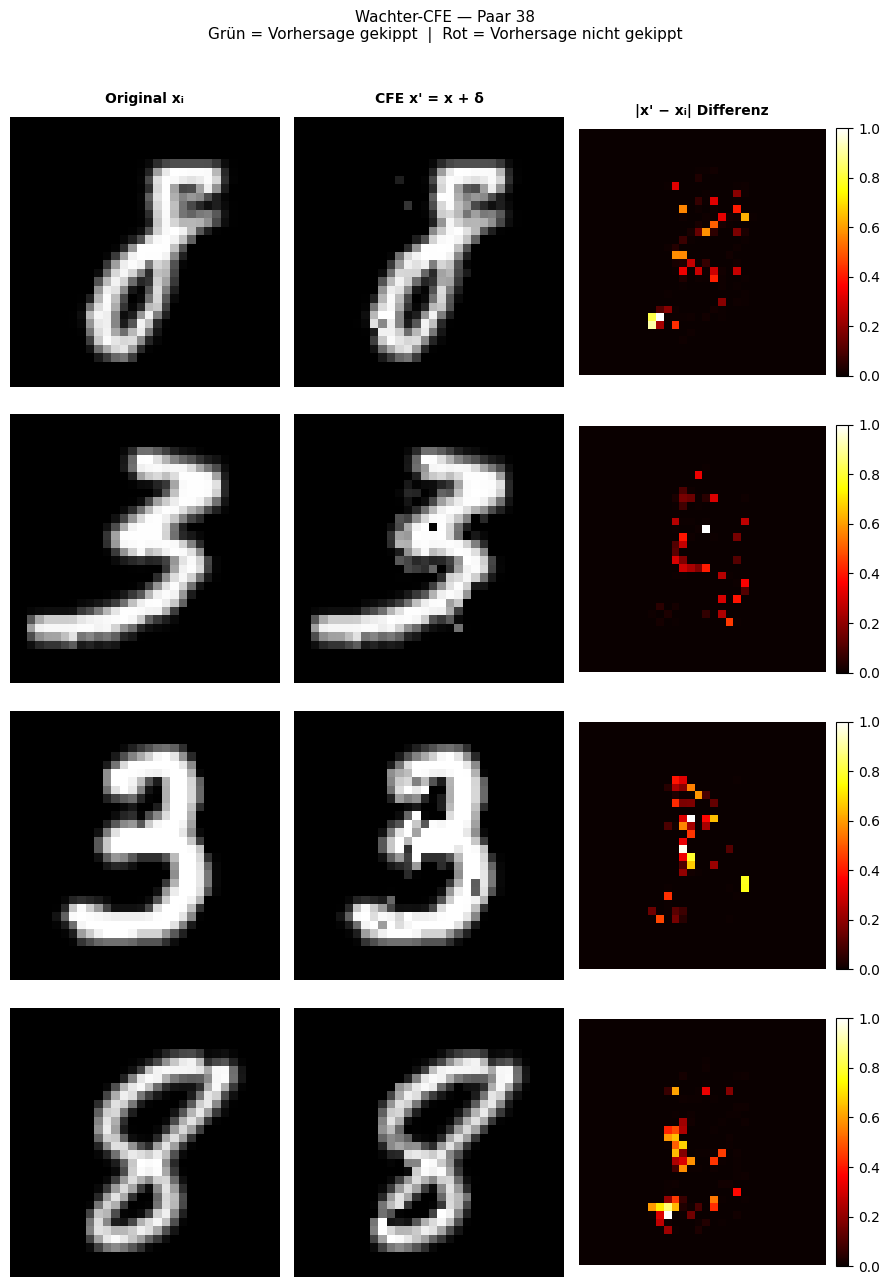

Gespeichert -> /kaggle/working/wachter_38.png


Wachter Evaluation: 100%|██████████| 5/5 [21:10<00:00, 254.10s/it]



Flip Rate (5 Batches): 40/40 = 100.00%
Fester Eval-Satz: 80 Bilder (Seed 42)
Berechne Metriken ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 10/10 [43:54<00:00, 263.45s/it]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 147MB/s] 
/tmp/ipykernel_23/1216792882.py:80: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
/tmp/ipykernel_23/1216792882.py:80: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)



METRIK-ERGEBNISSE — Wachter-CFE MNIST Paar 38

-- Proximity --
  L1-Distanz:           0.0079  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.2284  (niedriger = besser)
  LPIPS (SqueezeNet):   0.0308  (niedriger = besser)

-- Plausibilitaet --
  FID:                  95.54   (niedriger = besser)

-- Funktionalitaet --
  Validity:             8.75%  (hoeher = besser)
  Denoised Validity:    12.50%  (hoeher = besser, sigma=1.0)
  Delta Validity:       -3.75%  (niedriger = besser = weniger adversarial)
  Efficiency:           32.926s / CF  (niedriger = besser)

Ergebnis fuer Wachter / Paar 38 in /kaggle/working/metrics_summary.csv gespeichert.

######################################################################
# Wachter-CFE — Ziffernpaar 49 (4, 9)
######################################################################
Klassifikator-Checkpoint vorhanden: True
Klassen: {0: '4', 1: '9'}
Train (fuer MAD): 10612  Val (CF-Pool): 1179
Klassifikator geladen und eing

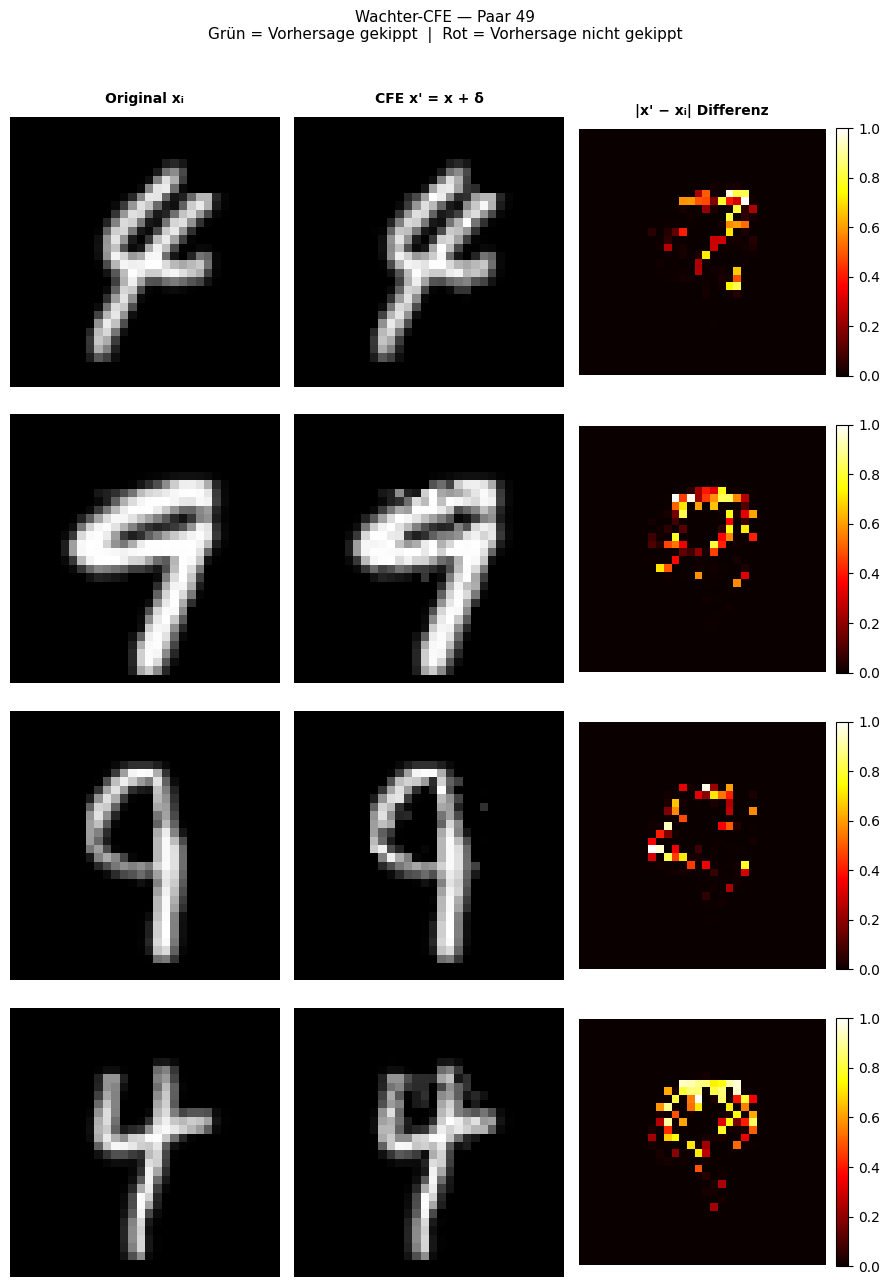

Gespeichert -> /kaggle/working/wachter_49.png


Wachter Evaluation: 100%|██████████| 5/5 [12:50<00:00, 154.10s/it]



Flip Rate (5 Batches): 40/40 = 100.00%
Fester Eval-Satz: 80 Bilder (Seed 42)
Berechne Metriken ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 10/10 [27:54<00:00, 167.44s/it]



METRIK-ERGEBNISSE — Wachter-CFE MNIST Paar 49

-- Proximity --
  L1-Distanz:           0.0091  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.2695  (niedriger = besser)
  LPIPS (SqueezeNet):   0.0403  (niedriger = besser)

-- Plausibilitaet --
  FID:                  85.44   (niedriger = besser)

-- Funktionalitaet --
  Validity:             31.25%  (hoeher = besser)
  Denoised Validity:    1.25%  (hoeher = besser, sigma=1.0)
  Delta Validity:       30.00%  (niedriger = besser = weniger adversarial)
  Efficiency:           20.927s / CF  (niedriger = besser)

Ergebnis fuer Wachter / Paar 49 in /kaggle/working/metrics_summary.csv gespeichert.

######################################################################
# Wachter-CFE — Ziffernpaar 56 (5, 6)
######################################################################
Klassifikator-Checkpoint vorhanden: True
Klassen: {0: '5', 1: '6'}
Train (fuer MAD): 10206  Val (CF-Pool): 1133
Klassifikator geladen und eing

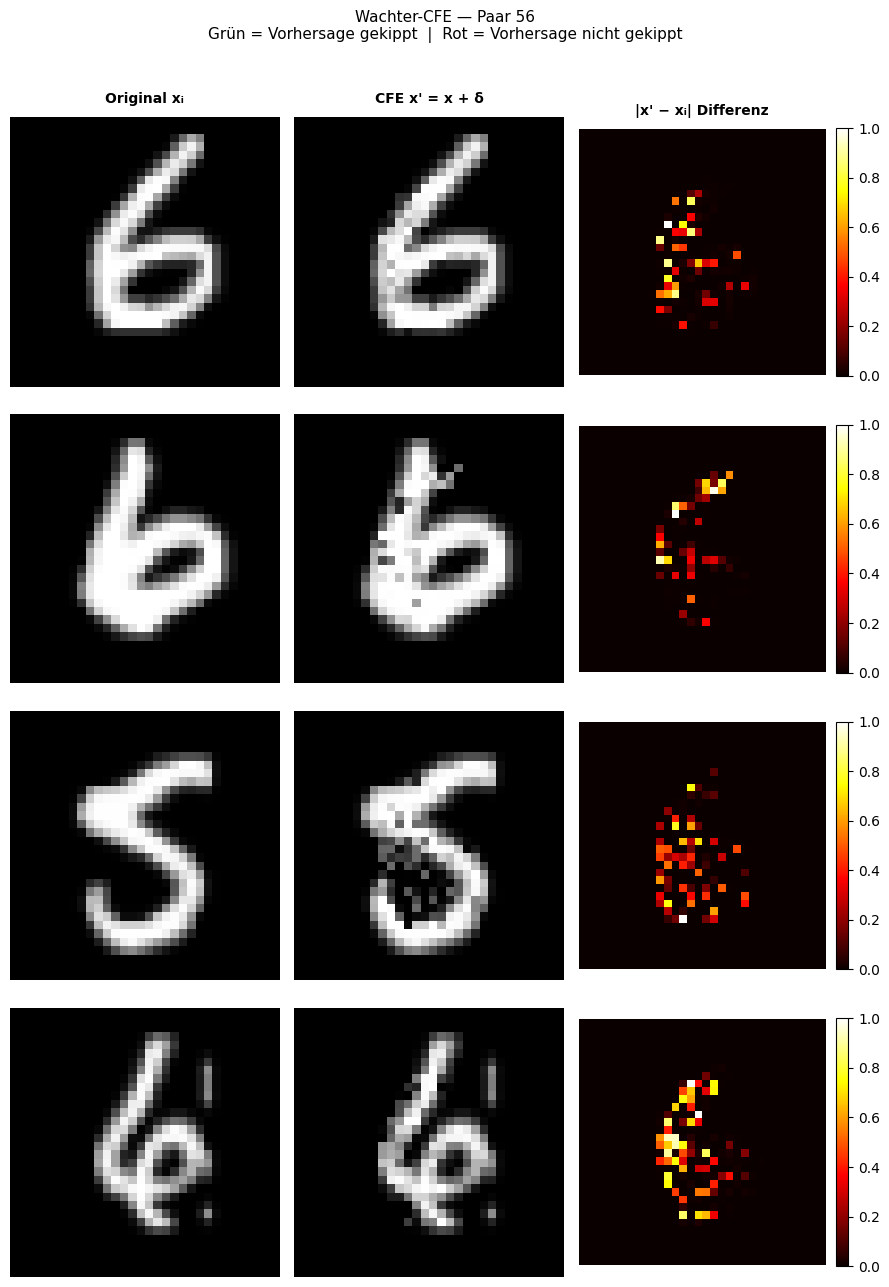

Gespeichert -> /kaggle/working/wachter_56.png


Wachter Evaluation: 100%|██████████| 5/5 [18:38<00:00, 223.75s/it]



Flip Rate (5 Batches): 40/40 = 100.00%
Fester Eval-Satz: 80 Bilder (Seed 42)
Berechne Metriken ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 10/10 [39:20<00:00, 236.00s/it]



METRIK-ERGEBNISSE — Wachter-CFE MNIST Paar 56

-- Proximity --
  L1-Distanz:           0.0115  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.2234  (niedriger = besser)
  LPIPS (SqueezeNet):   0.0516  (niedriger = besser)

-- Plausibilitaet --
  FID:                  104.05   (niedriger = besser)

-- Funktionalitaet --
  Validity:             8.75%  (hoeher = besser)
  Denoised Validity:    5.00%  (hoeher = besser, sigma=1.0)
  Delta Validity:       3.75%  (niedriger = besser = weniger adversarial)
  Efficiency:           29.497s / CF  (niedriger = besser)

Ergebnis fuer Wachter / Paar 56 in /kaggle/working/metrics_summary.csv gespeichert.

Alle 3 Ziffernpaare durchgelaufen.


In [10]:
all_results = []
for _pk in TASK_PAIRS:
    all_results.append(run_wachter_pipeline(_pk))

print('\n' + '=' * 70)
print('Alle 3 Ziffernpaare durchgelaufen.')
print('=' * 70)


## 10. Mittelwert ueber alle 3 Ziffernpaare

In [11]:
import pandas as pd

numeric_cols = ['l1', 'sparsity_rate', 'lpips', 'fid', 'validity', 'denoised_validity',
                'delta_validity', 'efficiency_sec']

df = pd.DataFrame(all_results)
mean_row = {'method': METHOD, 'pair_key': 'MEAN', 'digit_pair': 'Mittelwert ueber alle 3 Paare'}
for col in numeric_cols:
    vals = pd.to_numeric(df[col], errors='coerce')
    mean_row[col] = round(float(vals.mean()), 4)
mean_row['n_eval'] = N_EVAL_IMAGES
mean_row['eval_seed'] = EVAL_SEED

SUMMARY_PATH = os.path.join(OUT_DIR, 'metrics_summary.csv')
existing_rows = []
if os.path.exists(SUMMARY_PATH):
    with open(SUMMARY_PATH, newline='') as f:
        existing_rows = list(__import__('csv').DictReader(f))
existing_rows = [r for r in existing_rows if not (r['method'] == METHOD and r['pair_key'] == 'MEAN')]
existing_rows.append({k: str(v) for k, v in mean_row.items()})
fieldnames = list(existing_rows[0].keys()) if existing_rows else list(mean_row.keys())
with open(SUMMARY_PATH, 'w', newline='') as f:
    writer = __import__('csv').DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(existing_rows)

print('=' * 70)
print(f'METRIK-ERGEBNISSE — Wachter MNIST — MITTELWERT ueber alle 3 Ziffernpaare (N={len(all_results)})')
print('=' * 70)
print(f"\n-- Proximity --")
print(f"  L1-Distanz:           {mean_row['l1']:.4f}")
print(f"\n-- Interpretierbarkeit --")
print(f"  Sparsity Rate:        {mean_row['sparsity_rate']:.4f}")
print(f"  LPIPS (SqueezeNet):   {mean_row['lpips']:.4f}")
print(f"\n-- Plausibilitaet --")
print(f"  FID:                  {mean_row['fid']:.2f}")
print(f"\n-- Funktionalitaet --")
print(f"  Validity:             {mean_row['validity']:.2%}")
print(f"  Denoised Validity:    {mean_row['denoised_validity']:.2%}")
print(f"  Delta Validity:       {mean_row['delta_validity']:.2%}")
print(f"  Efficiency:           {mean_row['efficiency_sec']:.3f}s / CF")
print('=' * 70)

df_display = pd.DataFrame(all_results + [mean_row])
df_display


METRIK-ERGEBNISSE — Wachter MNIST — MITTELWERT ueber alle 3 Ziffernpaare (N=3)

-- Proximity --
  L1-Distanz:           0.0095

-- Interpretierbarkeit --
  Sparsity Rate:        0.2404
  LPIPS (SqueezeNet):   0.0409

-- Plausibilitaet --
  FID:                  95.01

-- Funktionalitaet --
  Validity:             16.25%
  Denoised Validity:    6.25%
  Delta Validity:       10.00%
  Efficiency:           27.783s / CF


,method,pair_key,digit_pair,l1,sparsity_rate,lpips,fid,validity,denoised_validity,delta_validity,efficiency_sec,n_eval,eval_seed
0,Wachter,38,3-8,0.0079,0.2284,0.0308,95.54,0.0875,0.1250,-0.0375,32.9261,80,42
1,Wachter,49,4-9,0.0091,0.2695,0.0403,85.44,0.3125,0.0125,0.3000,20.9266,80,42
2,Wachter,56,5-6,0.0115,0.2234,0.0516,104.05,0.0875,0.0500,0.0375,29.4974,80,42
3,Wachter,MEAN,Mittelwert ueber alle 3 Paare,0.0095,0.2404,0.0409,95.01,0.1625,0.0625,0.1000,27.7834,80,42
